In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# Force CPU if on Mac M1/M2 to prevent freezing, otherwise comment out for GPU
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF info logs

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [ ]:
# --- CONFIGURATION ---
DATASET_PATH = '/content/imaging'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
LEARNING_RATE = 0.0001

# Paths
TRAIN_DIR = os.path.join(DATASET_PATH, 'train')
TEST_DIR = os.path.join(DATASET_PATH, 'test')
VALID_DIR = os.path.join(DATASET_PATH, 'valid')

# Verify paths exist
if not os.path.exists(TRAIN_DIR):
    print(f"ERROR: Training folder not found at {TRAIN_DIR}")
else:
    print("Directories located successfully.")

Directories located successfully.


In [ ]:
print("--- Initializing Data Generators ---")

# 1. Augmentation for Training (The "Teacher")
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,      # Slight rotation
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# 2. No Augmentation for Validation/Test (The "Exam")
test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Load Data
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print(f"\nDetected Classes: {class_names}")

--- Initializing Data Generators ---
Found 612 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.

Detected Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


Sample Training Images (Augmented):


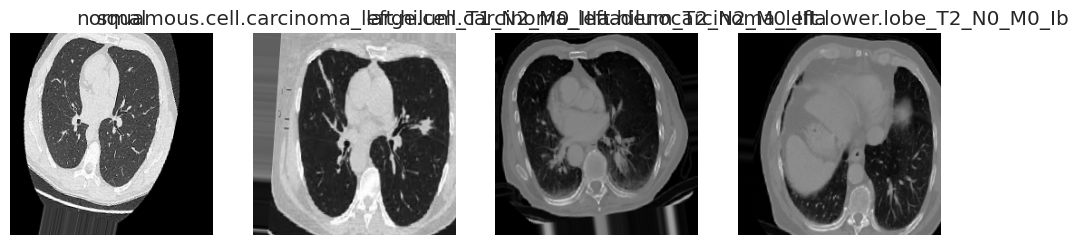

In [ ]:
# Helper to plot images
def plot_samples(generator):
    images, labels = next(generator)
    plt.figure(figsize=(12, 4))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.imshow(images[i])
        class_idx = np.argmax(labels[i])
        plt.title(class_names[class_idx])
        plt.axis('off')
    plt.show()

print("Sample Training Images (Augmented):")
plot_samples(train_generator)

In [ ]:
# Compute Weights
y_train_labels = train_generator.classes
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Convert to dictionary for Keras
class_weights = dict(enumerate(class_weights_array))

print("Class Weights calculated:")
for idx, weight in class_weights.items():
    print(f"  {class_names[idx]}: {weight:.2f}")

Class Weights calculated:
  adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 0.79
  large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 1.33
  normal: 1.03
  squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 0.99


In [ ]:
# ==========================================
# OPTIMIZED VGG16 BUILDER
# ==========================================
from tensorflow.keras.applications import VGG16

def build_imaging_model():
    print("--- Building Optimized VGG16 Model ---")

    # 1. Load VGG16 Base
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )

    # 2. Freeze Base (Strictly!)
    base_model.trainable = False

    # 3. Add Custom Head (Tuned for Small Data)
    model = Sequential([
        base_model,

        # Flatten vs GlobalAveragePooling:
        # For VGG on texture data (cancer), GlobalAverage is safer against overfitting.
        GlobalAveragePooling2D(),

        BatchNormalization(),

        # Dense Layer: Reduced to 512 (down from VGG standard 4096)
        Dense(512, activation='relu'),

        # Dropout: Keep high (0.5) to prevent memorization
        Dropout(0.5),

        # Output
        Dense(len(class_names), activation='softmax')
    ])

    # 4. Compile with LOWER Learning Rate
    model.compile(
        optimizer=Adam(learning_rate=0.0001), # <--- Changed from 0.001 to 0.0001
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Initialize
model = build_imaging_model()
model.summary()

--- Building Optimized VGG16 Model ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,981,444 (57.15 MB)

 Trainable params: 265,732 (1.01 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [ ]:
# Callbacks
checkpoint = ModelCheckpoint(
    'output/best_imaging_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-6
)

print("--- Starting Training ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=valid_generator,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

--- Starting Training ---
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.2722 - loss: 1.5342
Epoch 1: val_accuracy improved from -inf to 0.30556, saving model to output/best_imaging_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step - accuracy: 0.2745 - loss: 1.5299 - val_accuracy: 0.3056 - val_loss: 1.3772 - learning_rate: 1.0000e-04
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.5242 - loss: 1.0698
Epoch 2: val_accuracy improved from 0.30556 to 0.37500, saving model to output/best_imaging_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 284ms/step - accuracy: 0.5243 - loss: 1.0698 - val_accuracy: 0.3750 - val_loss: 1.2997 - learning_rate: 1.0000e-04
Epoch 3/50
38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.5442 - loss: 1.0337
Epoch 3: val_accuracy improved from 0.37500 to 0.41667, saving model to output/best_imaging_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 287ms/step - accuracy: 0.5456 - loss: 1.0302 - val_accuracy: 0.4167 - val_loss: 1.2435 - learning_rate: 1.0000e-04
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.5714 - loss: 0.9164
Epoch 4: val_accuracy improved from 0.41667 to 0.44444, saving model to output/best_imaging_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 299ms/step - accuracy: 0.5722 - loss: 0.9156 - val_accuracy: 0.4444 - val_loss: 1.1934 - learning_rate: 1.0000e-04
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.6215 - loss: 0.8772
Epoch 5: val_accuracy improved from 0.44444 to 0.50000, saving model to output/best_imaging_model.h5


...

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 288ms/step - accuracy: 0.8175 - loss: 0.4491 - val_accuracy: 0.7639 - val_loss: 0.6588 - learning_rate: 1.0000e-04
Epoch 24/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8567 - loss: 0.3786
Epoch 24: val_accuracy improved from 0.76389 to 0.80556, saving model to output/best_imaging_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 288ms/step - accuracy: 0.8567 - loss: 0.3784 - val_accuracy: 0.8056 - val_loss: 0.6523 - learning_rate: 1.0000e-04
Epoch 25/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8471 - loss: 0.3814
Epoch 25: val_accuracy did not improve from 0.80556
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.8470 - loss: 0.3819 - val_accuracy: 0.8056 - val_loss: 0.6369 - learning_rate: 1.0000e-04
Epoch 26/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8711 - loss: 0.3504
Epoch 26: val_accuracy did not improve from 0.80556
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 280ms/step - accuracy: 0.8709 - loss: 0.3512 - val_accuracy: 0.7917 - val_loss: 0.6394 - learning_rate: 1.0000e-04
Epoch 27/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8643 - loss: 0.3716
Epoch 27: val_accuracy did not improve from 0.80556
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 280ms/step - accuracy: 0.8643 - loss: 0.3715 - val_accuracy: 0.8056 - val_loss: 0.6308 - learning_rate: 1.0000e-04

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - accuracy: 0.8776 - loss: 0.3553 - val_accuracy: 0.8194 - val_loss: 0.6268 - learning_rate: 1.0000e-04
Epoch 30/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.8858 - loss: 0.3450
Epoch 30: val_accuracy did not improve from 0.81944
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 270ms/step - accuracy: 0.8853 - loss: 0.3454 - val_accuracy: 0.8194 - val_loss: 0.6160 - learning_rate: 1.0000e-04
Epoch 31/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8429 - loss: 0.3909
Epoch 31: val_accuracy did not improve from 0.81944
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - accuracy: 0.8433 - loss: 0.3905 - val_accuracy: 0.8056 - val_loss: 0.6166 - learning_rate: 1.0000e-04
Epoch 32/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.8941 - loss: 0.3215
Epoch 32: val_accuracy improved from 0.81944 to 0.83333, saving model to output/best_imaging_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 283ms/step - accuracy: 0.8939 - loss: 0.3221 - val_accuracy: 0.8333 - val_loss: 0.6168 - learning_rate: 1.0000e-04
Epoch 33/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8817 - loss: 0.3593
Epoch 33: val_accuracy improved from 0.83333 to 0.86111, saving model to output/best_imaging_model.h5


39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.8818 - loss: 0.3588 - val_accuracy: 0.8611 - val_loss: 0.6241 - learning_rate: 1.0000e-04
Epoch 34/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8669 - loss: 0.3527
Epoch 34: val_accuracy did not improve from 0.86111
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.8671 - loss: 0.3519 - val_accuracy: 0.8333 - val_loss: 0.6272 - learning_rate: 1.0000e-04
Epoch 35/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8960 - loss: 0.2906
Epoch 35: val_accuracy did not improve from 0.86111
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.8962 - loss: 0.2905 - val_accuracy: 0.8333 - val_loss: 0.6268 - learning_rate: 2.0000e-05
Epoch 36/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9062 - loss: 0.2670
Epoch 36: val_accuracy did not improve from 0.86111
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 279ms/step - accuracy: 0.9060 - loss: 0.2677 - val_accuracy: 0.8333 - val_loss: 0.6248 - learning_rate: 2.0000e-05

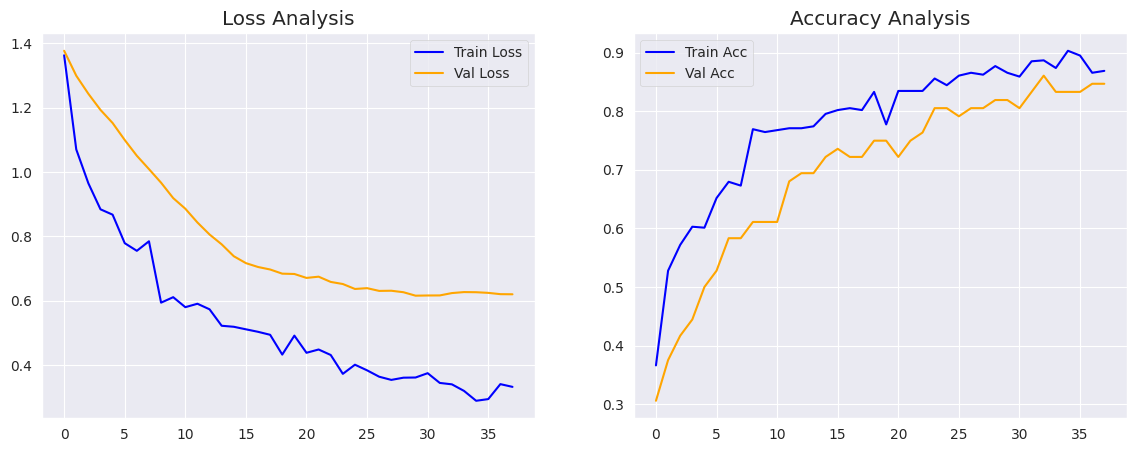

Generating Predictions on Test Set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 430ms/step


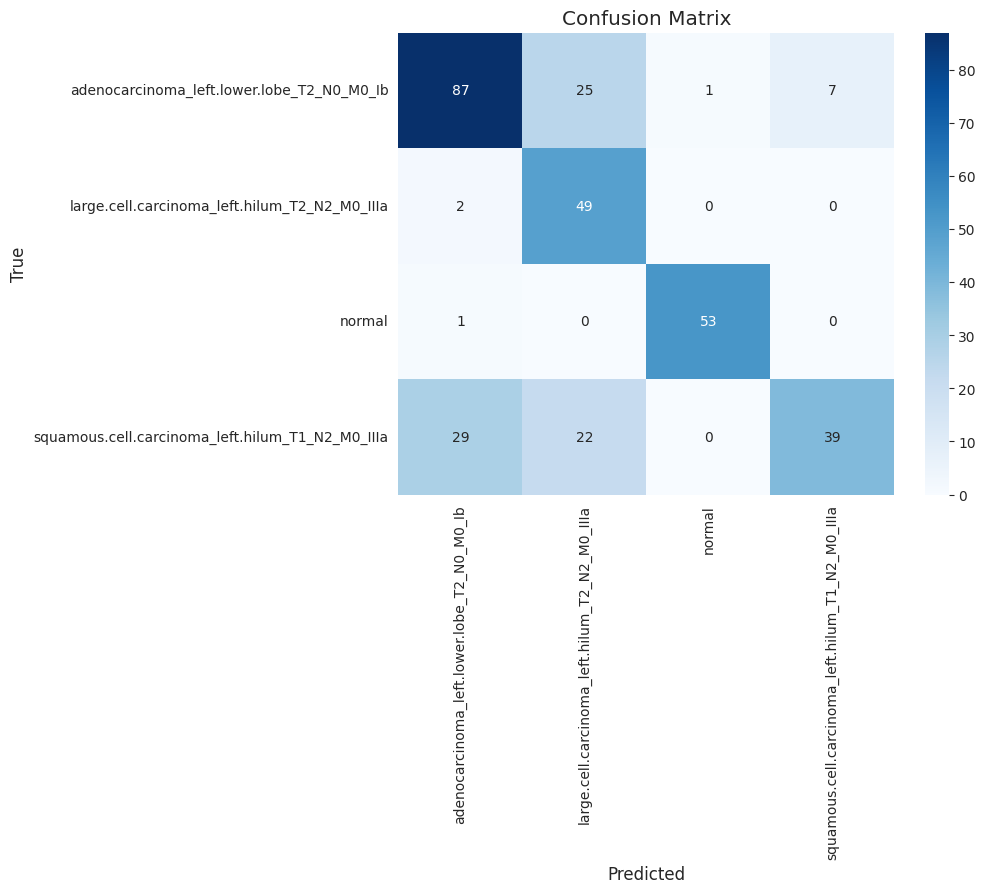


Classification Report:
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.73      0.72      0.73       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.51      0.96      0.67        51
                                          normal       0.98      0.98      0.98        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.85      0.43      0.57        90

                                        accuracy                           0.72       315
                                       macro avg       0.77      0.78      0.74       315
                                    weighted avg       0.77      0.72      0.72       315



In [ ]:
# 1. Plot Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Analysis')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Accuracy Analysis')
plt.legend()
plt.show()

# 2. Generate Predictions
print("Generating Predictions on Test Set...")
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# 3. Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 4. Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

--- Model Predictions on Test Data ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step


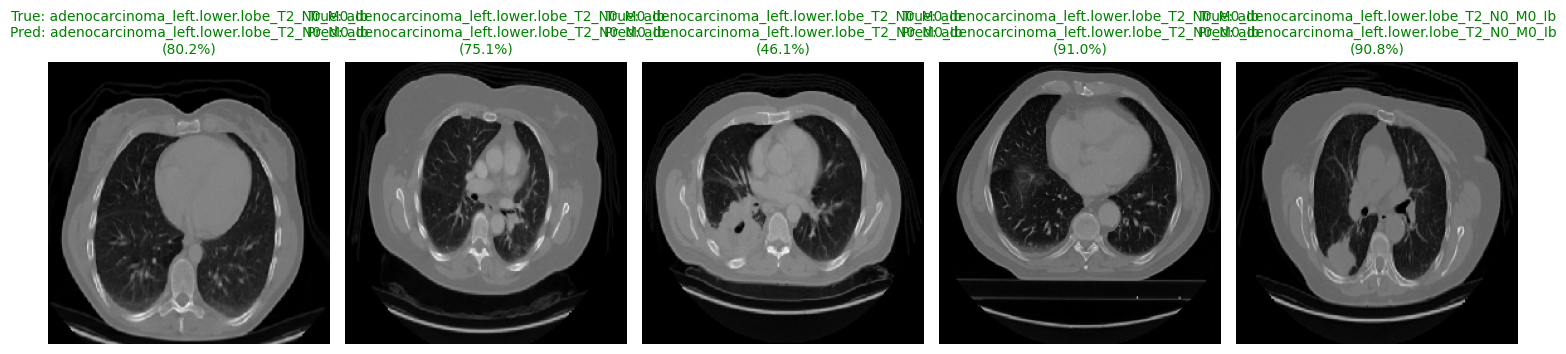

In [ ]:
def visualize_predictions(generator, model, num_images=5):
    # Get a batch of images
    images, labels = next(generator)
    preds = model.predict(images)

    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])

        true_idx = np.argmax(labels[i])
        pred_idx = np.argmax(preds[i])
        confidence = np.max(preds[i]) * 100

        color = 'green' if true_idx == pred_idx else 'red'
        title = f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]}\n({confidence:.1f}%)"

        plt.title(title, color=color, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("--- Model Predictions on Test Data ---")
visualize_predictions(test_generator, model, num_images=5)

In [ ]:
# ==========================================
# 8. ADVANCED EVALUATION: TEST TIME AUGMENTATION (TTA)
# ==========================================
print("\n--- Performing Test Time Augmentation (TTA) to boost Accuracy ---")

# 1. Define TTA Generator
# We use the same augmentations as training, but for the Test Set
tta_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

tta_generator = tta_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 2. Predict Multiple Times (e.g., 5 passes)
print("Running 5 prediction passes...")
preds_tta = []
for i in range(5):
    print(f"Pass {i+1}/5...")
    # Reset generator to start
    tta_generator.reset()
    preds = model.predict(tta_generator, verbose=0)
    preds_tta.append(preds)

# 3. Average the predictions
# This cancels out random errors
final_preds_tta = np.mean(preds_tta, axis=0)
y_pred_tta = np.argmax(final_preds_tta, axis=1)
y_true = tta_generator.classes

# 4. Evaluate
print("\n--- TTA Results ---")
print(classification_report(y_true, y_pred_tta, target_names=class_names))

# Check Accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred_tta)
print(f"Final Imaging Accuracy with TTA: {acc*100:.2f}%")

In [ ]:
import shap
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LIME (Image Explainer)
# ==========================================
print("Generating LIME Image Explanation...")
explainer = lime_image.LimeImageExplainer()

# Grab a batch
X_batch, y_batch = next(test_generator)
image_to_explain = X_batch[0].astype('double')

# Explain
explanation = explainer.explain_instance(
    image_to_explain, 
    model.predict, 
    top_labels=1, 
    hide_color=0, 
    num_samples=500 
)

# Show overlay
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0], 
    positive_only=True, 
    num_features=5, 
    hide_rest=False
)
plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
plt.title("LIME: Important Superpixels")
plt.show()
